In [2]:
import numpy as np
import matplotlib.pyplot as plt

(np.float64(8.963516887792413e-16),
 array([ 1.62625319e-18, -1.97155126e-19,  1.19149235e-17, ...,
         1.16149798e-17,  7.28281791e-18,  4.96475460e-18]))

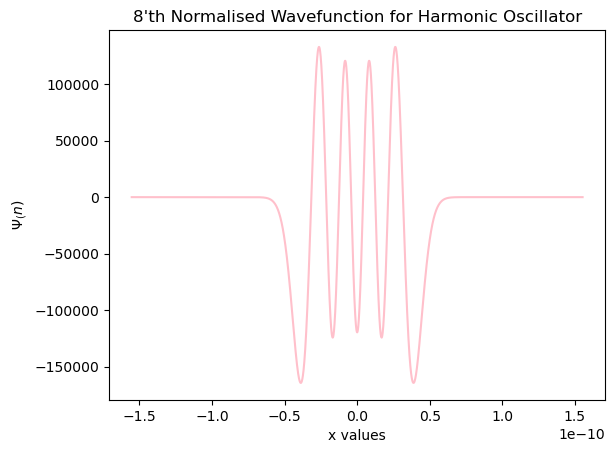

In [15]:
#setting constants and variable values
h = 6.626e-34
m = 9.1e-31
h_bar = h/(2*np.pi)


def harmonic_oscillator(n,w,N):
    """
    Solves the time-independent Schrodinger equation by creating a matrix eigenvalue problem,
    for a quantum harmonic oscillator.
    

    Inputs:
    n(int) : energy state to plot
    w (float): angular frequency of harmonic oscillator
    N (int): number of points in spatial grid

    Output:
    Plots the n"th energy normalised wavefunction of harmonic oscillator

    Returns:
    Energy (float) - n'th discrete energy the harmonic oscillator can exist in 
    Normalised Wavefunction (np array) - Corresponding normalised wavefunction
    """

    #Calculating how large the grid should be to show decay
    unc_x = np.sqrt((n+(1/2))*h_bar*1/(2*m*w))
    L = 7*unc_x

    
    dx = 2*L/(N+1)
    x_values = np.linspace(-L+dx,L-dx,N)
    x_values_squared = x_values**2


    #creating matrix to solve, this time needing to consider the potential along the grid
    coef_T = h_bar**2 /(2*m*dx**2)
    T  = coef_T * (np.diag(np.full(N,2)) - np.diag(np.ones(N-1),-1) - np.diag(np.ones(N-1),1))

    coef_V = 1/2 * m * w**2 
    V = coef_V * np.diag(x_values_squared)

    H = T+V

    energies, wavefunctions = np.linalg.eigh(H)

    psi_n = wavefunctions[:,n]
    normalised_psi_n= 1/np.sqrt(dx) * psi_n

    if n==1 :
        suffix = "'st"
    elif n==2:
        suffix = "'nd"
    elif n==3:
        suffix = "'rd"
    else:
        suffix = "'th"
        
    plt.figure()
    plt.title(f"{n}{suffix} Normalised Wavefunction for Harmonic Oscillator")
    plt.xlabel("x values")
    plt.ylabel(r"$\Psi_(n)$")
    plt.plot(x_values,normalised_psi_n,color='pink',)

    return energies[n], normalised_psi_n

    
    
    


harmonic_oscillator(8,10**18,4000)  



